In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [53]:
df = pd.read_csv("data/EV_Adoption_and_Range_Anxiety_Dataset.csv")
df.head()

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Buyer_ID                     10000 non-null  str    
 1   Age                          10000 non-null  int64  
 2   Gender                       10000 non-null  str    
 3   Annual_Income_USD            9822 non-null   float64
 4   City_Type                    10000 non-null  str    
 5   Daily_Commute_km             9819 non-null   float64
 6   Number_of_Cars_Owned         10000 non-null  int64  
 7   Current_Car_Type             10000 non-null  str    
 8   Charging_Stations_Near_Home  10000 non-null  int64  
 9   Charging_Stations_Near_Work  10000 non-null  int64  
 10  Home_Charging_Possible       10000 non-null  str    
 11  Environmental_Concern_Level  9816 non-null   float64
 12  Subsidy_Available            10000 non-null  str    
 13  Range_Anxiety_Level         

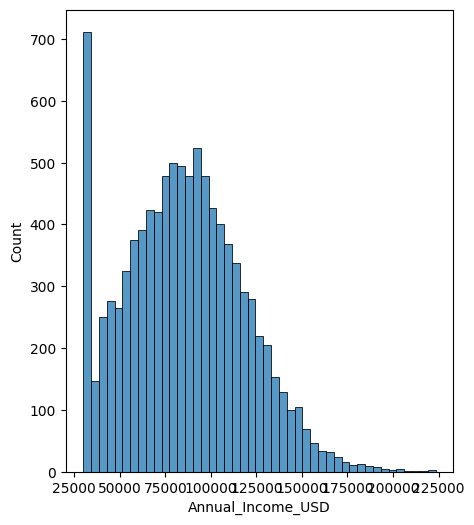

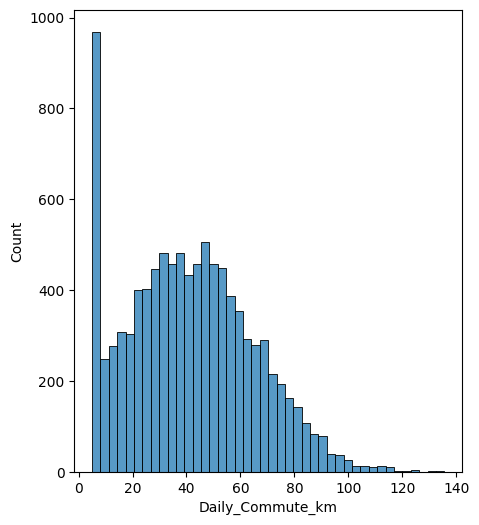

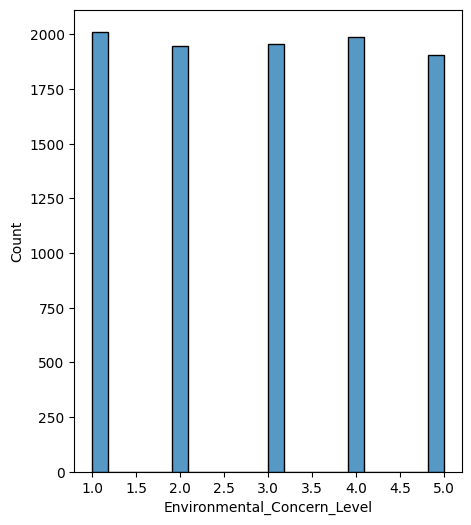

In [55]:
cols_to_treat = ["Annual_Income_USD","Daily_Commute_km","Environmental_Concern_Level"]
for i in cols_to_treat:
    plt.figure(figsize=(5,6))
    sns.histplot(df[i])

In [56]:
df.describe()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,10000.000000,9822.000000,9819.000000,10000.000000,10000.000000,10000.000000,9816.000000
mean,46.936200,85378.485848,41.105418,1.859900,5.346900,7.458200,2.982783
std,12.945968,32838.684167,23.351276,0.855421,4.049074,5.259374,1.413784
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,36.000000,61369.500000,23.250000,1.000000,2.000000,3.000000,2.000000
50%,47.000000,84708.000000,40.200000,2.000000,5.000000,6.000000,3.000000
75%,58.000000,107383.250000,57.000000,2.000000,8.000000,11.000000,4.000000
max,69.000000,223345.000000,135.500000,4.000000,14.000000,19.000000,5.000000


In [57]:
num_cols = df.describe().columns
num_cols

Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level'],
      dtype='str')

# Data cleaning


In [58]:
df["Gender"].value_counts()

Gender
Male      5201
Female    4498
Other      301
Name: count, dtype: int64

In [59]:
df["Gender"] = df["Gender"].map({"Male":1,"Female":0,"Other":2})

In [60]:
df["City_Type"].value_counts()

City_Type
Urban       4941
Suburban    3563
Rural       1496
Name: count, dtype: int64

In [61]:
from sklearn.preprocessing import LabelEncoder
encoder =  LabelEncoder()

In [62]:
df["City_Type"] = encoder.fit_transform(df["City_Type"])

In [63]:
df["City_Type"].value_counts()

City_Type
2    4941
1    3563
0    1496
Name: count, dtype: int64

encoding :

2 : Urban 
1 : Suburban
0 : Rural

In [64]:
df["Current_Car_Type"].value_counts()

Current_Car_Type
Sedan        4000
SUV          3486
Hatchback    1523
Truck         991
Name: count, dtype: int64

In [65]:
df["Current_Car_Type"]= encoder.fit_transform(df["Current_Car_Type"])

In [66]:
df["Current_Car_Type"].value_counts()

Current_Car_Type
2    4000
1    3486
0    1523
3     991
Name: count, dtype: int64

encoding  :

2 : Sedan , 1 : SUV , 0 : Hatchback , 3 : Truck 

In [67]:
bool_like_col = ["Home_Charging_Possible","Subsidy_Available","Will_Buy_EV"]

for i in bool_like_col:
    print(df[i].value_counts())

Home_Charging_Possible
Yes    6163
No     3837
Name: count, dtype: int64
Subsidy_Available
Yes    6008
No     3992
Name: count, dtype: int64
Will_Buy_EV
No     8250
Yes    1750
Name: count, dtype: int64


In [68]:
for i in bool_like_col:
    df[i] = df[i].map({"Yes":1,"No":0})

In [69]:
for i in bool_like_col:
    print(df[i].value_counts())

Home_Charging_Possible
1    6163
0    3837
Name: count, dtype: int64
Subsidy_Available
1    6008
0    3992
Name: count, dtype: int64
Will_Buy_EV
0    8250
1    1750
Name: count, dtype: int64


In [70]:
df["Range_Anxiety_Level"].value_counts()

Range_Anxiety_Level
Low       8310
Medium    1523
High       167
Name: count, dtype: int64

In [71]:
df["Range_Anxiety_Level"] = df["Range_Anxiety_Level"].map({"Low":0,"Medium":1,"High":2})

In [72]:
df["Range_Anxiety_Level"].value_counts()

Range_Anxiety_Level
0    8310
1    1523
2     167
Name: count, dtype: int64

encoding  :

0 : Low ,
1 : Medium ,
2 : High 

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Buyer_ID                     10000 non-null  str    
 1   Age                          10000 non-null  int64  
 2   Gender                       10000 non-null  int64  
 3   Annual_Income_USD            10000 non-null  float64
 4   City_Type                    10000 non-null  int32  
 5   Daily_Commute_km             10000 non-null  float64
 6   Number_of_Cars_Owned         10000 non-null  int64  
 7   Current_Car_Type             10000 non-null  int32  
 8   Charging_Stations_Near_Home  10000 non-null  int64  
 9   Charging_Stations_Near_Work  10000 non-null  int64  
 10  Home_Charging_Possible       10000 non-null  int64  
 11  Environmental_Concern_Level  10000 non-null  float64
 12  Subsidy_Available            10000 non-null  int64  
 13  Range_Anxiety_Level         

# Null imputation 

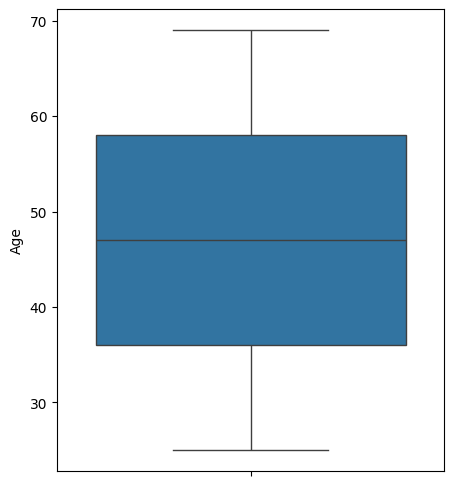

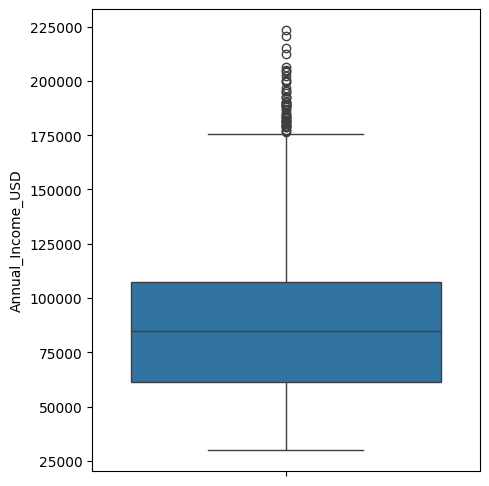

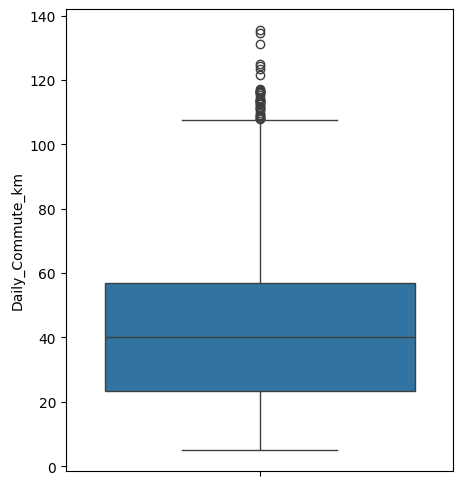

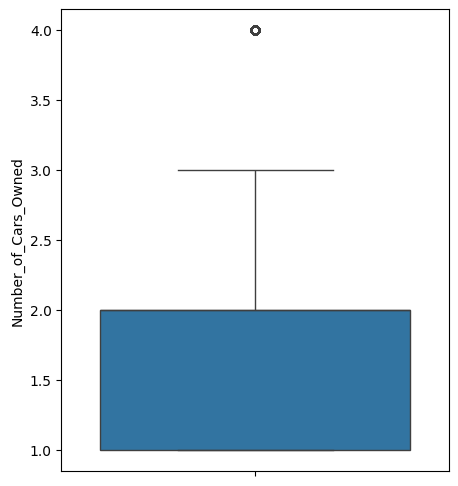

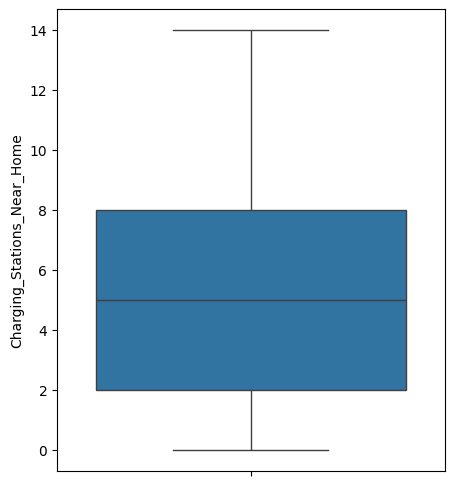

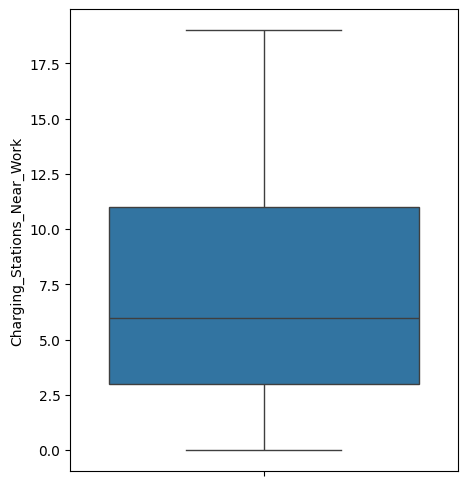

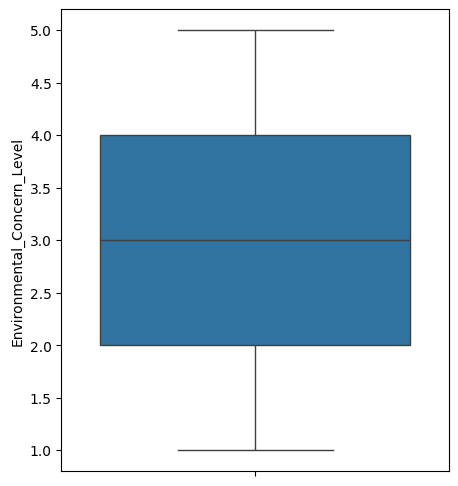

In [74]:
for i in num_cols :
    plt.figure(figsize=(5,6))
    sns.boxplot(df[i])

In [75]:
med = df.groupby("Number_of_Cars_Owned")["Annual_Income_USD"].median()
med


Number_of_Cars_Owned
1    84758.0
2    84287.0
3    84906.0
4    86877.0
Name: Annual_Income_USD, dtype: float64

In [76]:
df["Annual_Income_USD"] = df["Annual_Income_USD"].fillna(df["Number_of_Cars_Owned"].map(med))

In [77]:
df["Annual_Income_USD"].isna().sum()

0

In [78]:
med_km = df.groupby("Age")["Daily_Commute_km"].median()
med_km

Age
25    39.15
26    41.50
27    36.90
28    42.60
29    42.80
30    40.90
31    41.10
32    39.30
33    38.90
34    41.90
35    40.40
36    38.35
37    40.45
38    40.85
39    40.60
40    43.80
41    41.20
42    38.60
43    38.10
44    41.15
45    44.00
46    38.80
47    42.20
48    41.20
49    37.00
50    39.60
51    37.25
52    36.60
53    40.95
54    40.50
55    36.80
56    38.80
57    43.90
58    39.30
59    39.00
60    37.20
61    41.05
62    41.20
63    35.75
64    40.90
65    42.40
66    41.75
67    38.95
68    39.90
69    38.30
Name: Daily_Commute_km, dtype: float64

In [79]:
df["Daily_Commute_km"] = df["Daily_Commute_km"].fillna(df["Age"].map(med_km))


In [80]:
df["Daily_Commute_km"].isna().sum()

0

In [81]:
df["Environmental_Concern_Level"]=df["Environmental_Concern_Level"].fillna(df["Environmental_Concern_Level"].median())

In [82]:
df.isna().sum()

Buyer_ID                       0
Age                            0
Gender                         0
Annual_Income_USD              0
City_Type                      0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Current_Car_Type               0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Home_Charging_Possible         0
Environmental_Concern_Level    0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

# Handling outliers 

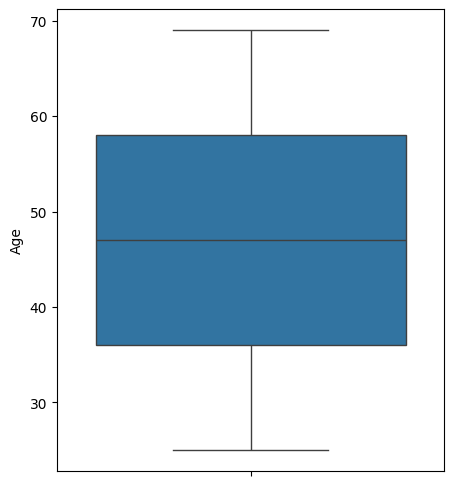

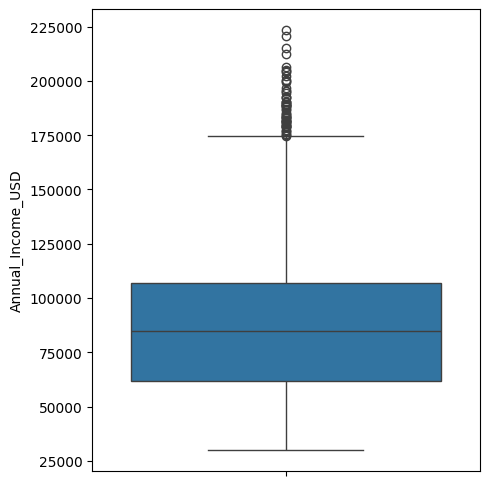

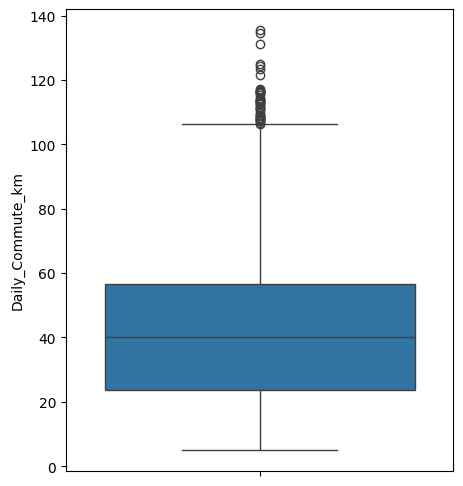

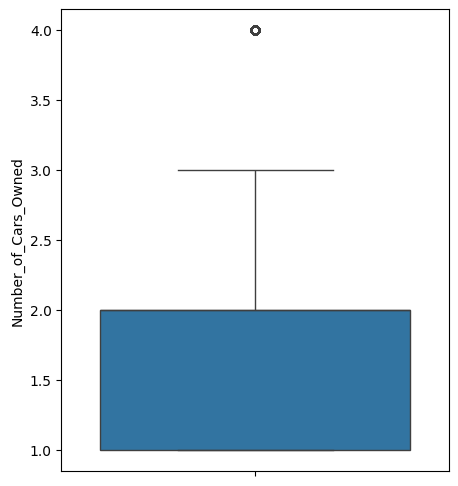

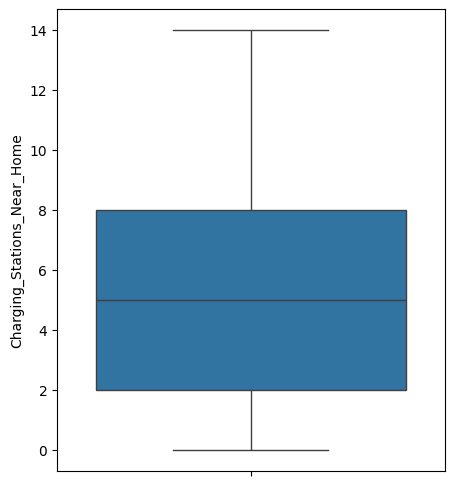

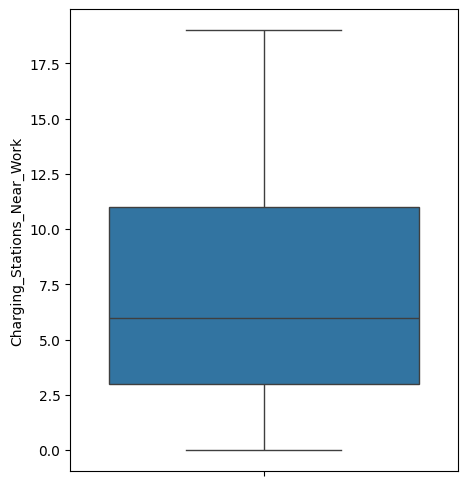

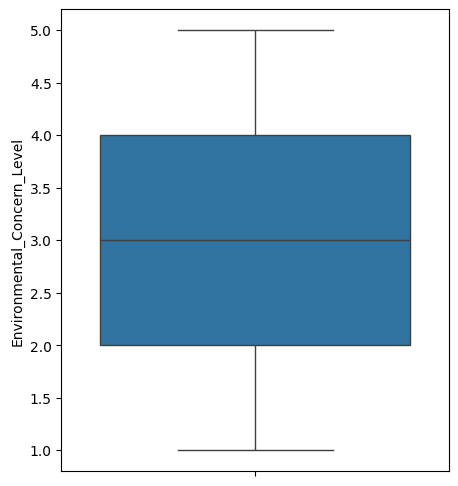

In [84]:
for i in num_cols :
    
    plt.figure(figsize=(5,6))
    sns.boxplot(df[i])

<Axes: ylabel='Annual_Income_USD'>

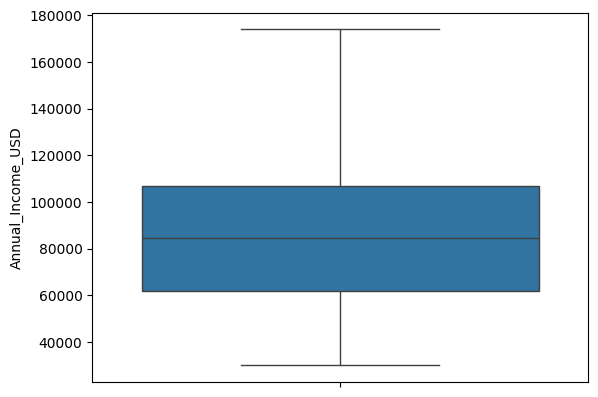

In [86]:
sns.boxplot(df["Annual_Income_USD"].clip(0,174000))

In [87]:
df["Annual_Income_USD"]=df["Annual_Income_USD"].clip(0,174000)

<Axes: ylabel='Daily_Commute_km'>

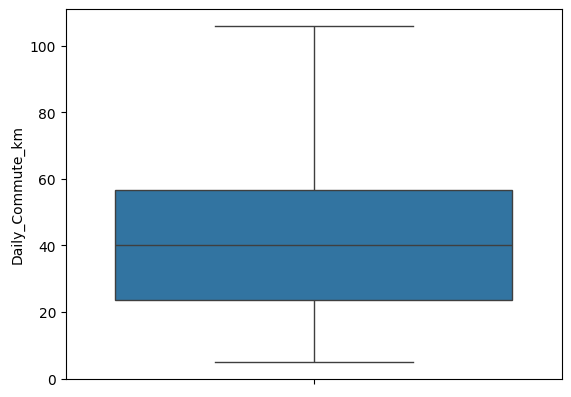

In [93]:
sns.boxplot(df["Daily_Commute_km"].clip(0,106))

In [94]:
df["Daily_Commute_km"]=df["Daily_Commute_km"].clip(0,106)

In [95]:
final_df = df.drop(["Buyer_ID"],axis=1)

In [96]:
final_df

,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,56,1,44906.0,0,18.1,1,3,1,0,1,4.0,1,0,0
1,36,1,88754.0,0,5.0,1,1,2,3,1,1.0,1,0,0
2,42,1,155958.0,2,32.2,2,2,14,3,0,2.0,1,1,1
3,31,1,37059.0,0,89.9,1,2,2,1,1,4.0,0,0,0
4,48,0,48552.0,0,71.0,1,2,2,0,1,3.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,50,1,61279.0,2,71.4,1,2,8,3,0,3.0,1,1,0
9996,34,1,108208.0,2,48.0,2,0,9,7,0,5.0,0,0,0
9997,60,0,97743.0,2,9.0,2,2,10,3,0,5.0,1,0,0
9998,31,0,103628.0,2,81.8,2,1,10,10,1,1.0,1,0,0


In [110]:
final_df.to_csv("data/modified_data.csv",index=False)

In [111]:
test = pd.read_csv("data/modified_data.csv")

In [112]:
test

,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,56,1,44906.0,0,18.1,1,3,1,0,1,4.0,1,0,0
1,36,1,88754.0,0,5.0,1,1,2,3,1,1.0,1,0,0
2,42,1,155958.0,2,32.2,2,2,14,3,0,2.0,1,1,1
3,31,1,37059.0,0,89.9,1,2,2,1,1,4.0,0,0,0
4,48,0,48552.0,0,71.0,1,2,2,0,1,3.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,50,1,61279.0,2,71.4,1,2,8,3,0,3.0,1,1,0
9996,34,1,108208.0,2,48.0,2,0,9,7,0,5.0,0,0,0
9997,60,0,97743.0,2,9.0,2,2,10,3,0,5.0,1,0,0
9998,31,0,103628.0,2,81.8,2,1,10,10,1,1.0,1,0,0
